In [1]:
import pandas as pd

# Demand

## 취약계층

In [2]:
df_elderly = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/elderly_score.csv')
df_lowincome = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/lowincome_index.csv')
df_disabled = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/disabled_index.csv')

In [3]:
df_elderly.head()

,행정동코드,자치구,행정동,ELDERLY_SCORE
0,11010530,종로구,사직동,69
1,11010540,종로구,삼청동,42
2,11010550,종로구,부암동,46
3,11010560,종로구,평창동,57
4,11010570,종로구,무악동,48


In [4]:
df_elderly.describe()

,행정동코드,ELDERLY_SCORE
count,4.250000e+02,425.000000
mean,1.113672e+07,60.247059
std,7.404713e+04,9.661861
min,1.101053e+07,0.000000
25%,1.107070e+07,54.000000
50%,1.114069e+07,60.000000
75%,1.120073e+07,66.000000
max,1.125076e+07,100.000000


In [5]:
df_lowincome.columns = ['자치구', '행정동', '행정동코드', 'PVI']

In [6]:
df_lowincome.head()

,자치구,행정동,행정동코드,PVI
0,노원구,중계2·3동,11110780,100
1,강서구,등촌3동,11160540,89
2,성북구,장위1동,11080760,87
3,강서구,가양3동,11160660,81
4,강동구,암사1동,11250720,80


In [7]:
df_lowincome.describe()

,행정동코드,PVI
count,4.250000e+02,425.000000
mean,1.113672e+07,28.663529
std,7.404713e+04,16.576359
min,1.101053e+07,0.000000
25%,1.107070e+07,15.000000
50%,1.114069e+07,25.000000
75%,1.120073e+07,38.000000
max,1.125076e+07,100.000000


In [8]:
df_disabled.drop(columns=['순위'], inplace=True)

In [9]:
df_disabled.columns = ['자치구', '행정동', '행정동코드', 'disabled_index']

In [10]:
df_disabled.head()

,자치구,행정동,행정동코드,disabled_index
0,강서구,등촌3동,11160540,100
1,강서구,가양3동,11160660,93
2,강동구,천호3동,11250630,87
3,강동구,암사1동,11250720,86
4,관악구,청림동,11210540,84


In [11]:
df_disabled.describe()

,행정동코드,disabled_index
count,4.250000e+02,425.000000
mean,1.113667e+07,56.440000
std,7.399412e+04,20.101788
min,1.101053e+07,0.000000
25%,1.107070e+07,54.000000
50%,1.114069e+07,63.000000
75%,1.120073e+07,70.000000
max,1.125076e+07,100.000000


In [12]:
# 1. 각 데이터프레임의 '행정동코드'를 set으로 변환
codes_df1 = set(df_elderly['행정동코드'])
codes_df2 = set(df_disabled['행정동코드'])

print(len(codes_df1))
print(len(codes_df2))

# 2. df1에는 있는데 df2에는 없는 코드
only_in_df1 = codes_df1 - codes_df2

# 3. df2에는 있는데 df1에는 없는 코드
only_in_df2 = codes_df2 - codes_df1

# 4. 결과 출력
print(f"df1에만 있는 코드 개수: {len(only_in_df1)}")
print(f"df2에만 있는 코드 개수: {len(only_in_df2)}")

# 구체적인 코드 목록을 보고 싶다면:
print("df1에만 있는 코드 목록:", only_in_df1)
print("df2에만 있는 코드 목록:", only_in_df2)

425
424
df1에만 있는 코드 개수: 1
df2에만 있는 코드 개수: 0
df1에만 있는 코드 목록: {11230510}
df2에만 있는 코드 목록: set()


In [13]:
# 찾으려는 행정동코드 리스트
target_codes = [11210680, 11230510]

# 행정동코드가 target_codes에 포함된 행만 필터링
# 행정동코드의 데이터 타입이 문자열(str)인 경우 [str(code) for code in target_codes]로 수정하세요.
result = df_disabled[df_disabled['행정동코드'].isin(target_codes)]

# 결과 확인
print(result)

     자치구  행정동     행정동코드  disabled_index
72   관악구  신사동  11210680              71
303  강남구  신사동  11210680              56


In [14]:
# .iloc을 사용하여 303번째 행(index 303)의 '행정동코드' 컬럼 값을 11230510으로 변경
df_disabled.iloc[303, df_disabled.columns.get_loc('행정동코드')] = 11230510

# 수정 확인 (잘 변경되었는지 해당 행을 출력해서 확인)
print(df_disabled.iloc[303])

자치구                    강남구
행정동                    신사동
행정동코드             11230510
disabled_index          56
Name: 303, dtype: object


## 1인 가구/사회적 고립

In [15]:
df_living = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/living_score.csv')

In [16]:
df_living.head()

,행정동코드,자치구,행정동,사회적_고립도,1인가구_지수
0,11010530,종로구,사직동,48,32
1,11010540,종로구,삼청동,38,43
2,11010550,종로구,부암동,27,35
3,11010560,종로구,평창동,16,17
4,11010570,종로구,무악동,61,33


In [17]:
df_living.describe()

,행정동코드,사회적_고립도,1인가구_지수
count,4.250000e+02,425.000000,425.000000
mean,1.113672e+07,65.218824,32.762353
std,7.404713e+04,19.408752,13.053500
min,1.101053e+07,0.000000,0.000000
25%,1.107070e+07,57.000000,25.000000
50%,1.114069e+07,69.000000,32.000000
75%,1.120073e+07,79.000000,39.000000
max,1.125076e+07,100.000000,100.000000


# SupplyGap

## HVI

In [18]:
df_hvi = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/B068_HVI.csv')

In [19]:
df_hvi.columns = ['행정동코드', '자치구', '행정동', 'HVI_index', 'reliability']

In [20]:
# 1. 각 데이터프레임의 '행정동코드'를 set으로 변환
codes_df1 = set(df_elderly['행정동코드'])
codes_df2 = set(df_hvi['행정동코드'])

print(len(codes_df1))
print(len(codes_df2))

# 2. df1에는 있는데 df2에는 없는 코드
only_in_df1 = codes_df1 - codes_df2

# 3. df2에는 있는데 df1에는 없는 코드
only_in_df2 = codes_df2 - codes_df1

# 4. 결과 출력
print(f"df1에만 있는 코드 개수: {len(only_in_df1)}")
print(f"df2에만 있는 코드 개수: {len(only_in_df2)}")

# 구체적인 코드 목록을 보고 싶다면:
print("df1에만 있는 코드 목록:", only_in_df1)
print("df2에만 있는 코드 목록:", only_in_df2)

425
425
df1에만 있는 코드 개수: 3
df2에만 있는 코드 개수: 3
df1에만 있는 코드 목록: {11020600, 11240770, 11160660}
df2에만 있는 코드 목록: {11240760, 11020530, 11150680}


In [21]:
# 찾으려는 행정동코드 리스트
target_codes = [11240760, 11020530, 11150680]

# 행정동코드가 target_codes에 포함된 행만 필터링
# 행정동코드의 데이터 타입이 문자열(str)인 경우 [str(code) for code in target_codes]로 수정하세요.
result = df_hvi[df_hvi['행정동코드'].isin(target_codes)]

# 결과 확인
print(result)

        행정동코드  자치구   행정동  HVI_index reliability
416  11150680  강서구  가양3동          0    excluded
423  11240760  송파구  잠실6동          0    excluded
424  11020530   중구  을지로동          0    excluded


In [22]:
# .iloc을 사용하여 n번째 행의 '행정동코드' 컬럼 값을 변경
df_hvi.iloc[416, df_hvi.columns.get_loc('행정동코드')] = 11160660

# 수정 확인 (잘 변경되었는지 해당 행을 출력해서 확인)
print(df_hvi.iloc[416])

# .iloc을 사용하여 n번째 행의 '행정동코드' 컬럼 값을 변경
df_hvi.iloc[423, df_hvi.columns.get_loc('행정동코드')] = 11240770

# 수정 확인 (잘 변경되었는지 해당 행을 출력해서 확인)
print(df_hvi.iloc[423])

# .iloc을 사용하여 n번째 행의 '행정동코드' 컬럼 값을 변경
df_hvi.iloc[424, df_hvi.columns.get_loc('행정동코드')] = 11020600

# 수정 확인 (잘 변경되었는지 해당 행을 출력해서 확인)
print(df_hvi.iloc[424])

행정동코드          11160660
자치구                 강서구
행정동                가양3동
HVI_index             0
reliability    excluded
Name: 416, dtype: object
행정동코드          11240770
자치구                 송파구
행정동                잠실6동
HVI_index             0
reliability    excluded
Name: 423, dtype: object
행정동코드          11020600
자치구                  중구
행정동                을지로동
HVI_index             0
reliability    excluded
Name: 424, dtype: object


In [23]:
# HVI_index가 0인 행정동 데이터 필터링
hvi_zero_dongs = df_hvi[df_hvi['HVI_index'] == 0]

# 결과 확인 (행정동 명칭 위주로 출력)
print(hvi_zero_dongs[['자치구', '행정동', 'HVI_index']])

     자치구   행정동  HVI_index
365  강남구  일원본동          0
412   중구   소공동          0
413  양천구  신정6동          0
414  송파구  잠실7동          0
415  강동구  둔촌1동          0
416  강서구  가양3동          0
417  송파구  문정2동          0
418  서초구  반포본동          0
419  노원구  상계8동          0
420  노원구  상계9동          0
421  송파구   오륜동          0
422  송파구  잠실2동          0
423  송파구  잠실6동          0
424   중구  을지로동          0


In [24]:
df_hvi.head()

,행정동코드,자치구,행정동,HVI_index,reliability
0,11010530,종로구,사직동,34,high
1,11010540,종로구,삼청동,5,high
2,11010550,종로구,부암동,47,high
3,11010560,종로구,평창동,35,high
4,11010570,종로구,무악동,35,high


In [25]:
df_hvi.describe()

,행정동코드,HVI_index
count,4.250000e+02,425.000000
mean,1.113672e+07,51.527059
std,7.404713e+04,20.650274
min,1.101053e+07,0.000000
25%,1.107070e+07,39.000000
50%,1.114069e+07,52.000000
75%,1.120073e+07,66.000000
max,1.125076e+07,100.000000


## 인프라

In [26]:
df_infra = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/infra_score.csv')

In [27]:
df_infra.columns = ['자치구', '행정동', '행정동코드', '인프라지수']

In [28]:
# 인프라지수 반전 (100점 만점 기준)
df_infra['인프라지수'] = 100 - df_infra['인프라지수']

In [29]:
df_infra.head()

,자치구,행정동,행정동코드,인프라지수
0,강남구,개포1동,11230680,82
1,강남구,개포2동,11230800,33
2,강남구,개포3동,11230511,53
3,강남구,개포4동,11230710,41
4,강남구,논현1동,11230520,24


In [30]:
df_infra.describe()

,행정동코드,인프라지수
count,4.250000e+02,425.000000
mean,1.113672e+07,38.969412
std,7.404713e+04,15.933574
min,1.101053e+07,0.000000
25%,1.107070e+07,28.000000
50%,1.114069e+07,39.000000
75%,1.120073e+07,48.000000
max,1.125076e+07,100.000000


## 재난

In [31]:
df_disaster = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/disaster_score.csv')

In [32]:
df_disaster.head()

,행정동코드,자치구,행정동,DISASTER_SCORE
0,11010530,종로구,사직동,31
1,11010540,종로구,삼청동,31
2,11010550,종로구,부암동,30
3,11010560,종로구,평창동,43
4,11010570,종로구,무악동,2


In [33]:
df_disaster.describe()

,행정동코드,DISASTER_SCORE
count,4.250000e+02,425.000000
mean,1.113672e+07,36.512941
std,7.404713e+04,13.437151
min,1.101053e+07,0.000000
25%,1.107070e+07,27.000000
50%,1.114069e+07,36.000000
75%,1.120073e+07,45.000000
max,1.125076e+07,100.000000


##치안

In [34]:
df_crime = pd.read_csv('/content/drive/MyDrive/비타민/서울시 공모전/최종 지수/crime_score.csv')

In [35]:
df_crime.head()

,행정동코드,자치구,행정동,CRIME_SCORE
0,11010530,종로구,사직동,38
1,11010540,종로구,삼청동,39
2,11010550,종로구,부암동,28
3,11010560,종로구,평창동,43
4,11010570,종로구,무악동,46


In [36]:
df_crime.describe()

,행정동코드,CRIME_SCORE
count,4.250000e+02,425.000000
mean,1.113672e+07,51.016471
std,7.404713e+04,22.556161
min,1.101053e+07,0.000000
25%,1.107070e+07,34.000000
50%,1.114069e+07,50.000000
75%,1.120073e+07,69.000000
max,1.125076e+07,100.000000


# 합치기

In [37]:
import pandas as pd
from functools import reduce

# 1. 병합할 리스트 정의 (행정동코드와 각 지수 컬럼만 남김)
# '자치구', '행정동'은 나중에 붙일 거라 여기서 미리 뺍니다.
clean_df_list = [
    df_elderly[['행정동코드', 'ELDERLY_SCORE']],
    df_lowincome[['행정동코드', 'PVI']],
    df_disabled[['행정동코드', 'disabled_index']],
    df_living[['행정동코드', '1인가구_지수', '사회적_고립도']],
    df_hvi[['행정동코드', 'HVI_index']],
    df_infra[['행정동코드', '인프라지수']],
    df_disaster[['행정동코드', 'DISASTER_SCORE']],
    df_crime[['행정동코드', 'CRIME_SCORE']]
]

# 2. 행정동코드 기준으로 모든 지수 통합
df_indices = reduce(lambda left, right: pd.merge(left, right, on='행정동코드', how='left'), clean_df_list)

# 3. 마지막 단계: 자치구/행정동 정보를 가진 '마스터 테이블'과 병합
# (df_elderly나 dong_df 중 하나를 참조 테이블로 사용하세요)
final_df = pd.merge(
    df_indices,
    df_elderly[['행정동코드', '자치구', '행정동']],
    on='행정동코드',
    how='left'
)

# 4. 컬럼 순서 재배치 (자치구, 행정동을 앞으로 보내면 보기 좋습니다)
cols = ['행정동코드', '자치구', '행정동'] + [col for col in final_df.columns if col not in ['자치구', '행정동', '행정동코드']]
final_df = final_df[cols]

# 결과 확인
print(final_df.head())

      행정동코드  자치구  행정동  ELDERLY_SCORE  PVI  disabled_index  1인가구_지수  사회적_고립도  \
0  11010530  종로구  사직동             69   11               6       32       48   
1  11010540  종로구  삼청동             42    9              53       43       38   
2  11010550  종로구  부암동             46   15              51       35       27   
3  11010560  종로구  평창동             57   13              53       17       16   
4  11010570  종로구  무악동             48   18              61       33       61   

   HVI_index  인프라지수  DISASTER_SCORE  CRIME_SCORE  
0         34     12              31           38  
1          5     63              31           39  
2         47     75              30           28  
3         35     83              43           43  
4         35     78               2           46  


In [38]:
print(len(final_df))

425


In [39]:
print(final_df.columns)

Index(['행정동코드', '자치구', '행정동', 'ELDERLY_SCORE', 'PVI', 'disabled_index',
       '1인가구_지수', '사회적_고립도', 'HVI_index', '인프라지수', 'DISASTER_SCORE',
       'CRIME_SCORE'],
      dtype='object')


## 지수 1 - 설정 가중치

In [40]:
import numpy as np

# 1. 수요지수 계산: 취약계층 (ELDERLY_SCORE, disabled_index, PVI 활용)
# max()는 행(axis=1) 단위로 계산합니다.
vulnerable_max = final_df[['ELDERLY_SCORE', 'disabled_index', 'PVI']].max(axis=1)
vulnerable = (0.5 * final_df['ELDERLY_SCORE'] +
              0.3 * final_df['disabled_index'] +
              0.2 * final_df['PVI']) * (1 + 0.3 * vulnerable_max)

vulnerable_scaled = (vulnerable - vulnerable.min()) / (vulnerable.max() - vulnerable.min()) * 100

# Demand(수요지수) 계산
final_df['Demand_1'] = (0.7 * vulnerable_scaled +
                      0.1 * final_df['1인가구_지수'] +
                      0.2 * final_df['사회적_고립도'])

# 2. 공급지수 계산 (SupplyGap)
final_df['Supply'] = (0.3 * final_df['HVI_index'] +
                      0.3 * final_df['인프라지수'] +
                      0.2 * final_df['DISASTER_SCORE'] +
                      0.2 * final_df['CRIME_SCORE'])

# 1. 기하평균(Geometric Mean) 방식으로 Raw Score 산출
# 수요와 공급 결핍의 상호 증폭 효과를 반영합니다.
final_df['raw_score_1'] = np.sqrt(final_df['Demand_1'] * final_df['Supply'])

# 2. 0~100 범위로 재정규화 (Min-Max Scaling)
# 점수 분포를 넓게 펼쳐 행정동 간의 변별력을 극대화합니다.
min_val = final_df['raw_score_1'].min()
max_val = final_df['raw_score_1'].max()

final_df['Final_Score_1'] = ((final_df['raw_score_1'] - min_val) / (max_val - min_val)) * 100

# 3. 반올림 후 정수형(int)으로 변환
final_df['Final_Score_1'] = final_df['Final_Score_1'].round().astype(int)

# 결과 확인
final_df[['자치구', '행정동', 'Demand_1', 'Supply', 'Final_Score_1']].head(10)

,자치구,행정동,Demand_1,Supply,Final_Score_1
0,종로구,사직동,27.775000,27.6,28
1,종로구,삼청동,21.539118,34.4,27
2,종로구,부암동,19.102647,48.2,34
3,종로구,평창동,20.323529,52.6,39
4,종로구,무악동,31.957941,43.5,49
5,종로구,교남동,37.387059,41.5,54
6,종로구,가회동,30.822941,33.6,38
7,종로구,종로1·2·3·4가동,46.147059,57.0,80
8,종로구,종로5·6가동,43.320588,51.7,71
9,종로구,이화동,25.612647,34.7,32


In [41]:
final_df[['행정동코드', '자치구', '행정동', 'Demand_1', 'Supply', 'Final_Score_1']].to_csv(
    'final_score.csv',
    index=False,
    encoding='utf-8-sig'
)

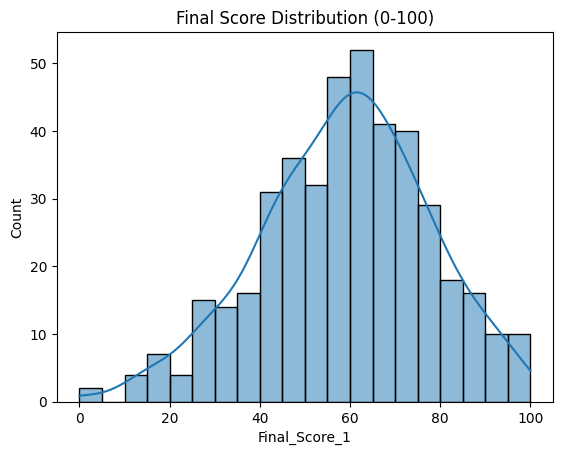

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_df['Final_Score_1'], bins=20, kde=True)
plt.title('Final Score Distribution (0-100)')
plt.show()

## 지수 2 - 동일 가중치

In [43]:
# Demand(수요지수) 계산
final_df['Demand_2'] = (0.2 * final_df['ELDERLY_SCORE'] +
                        0.2 * final_df['disabled_index'] +
                        0.2 * final_df['PVI'] +
                        0.2 * final_df['1인가구_지수'] +
                        0.2 * final_df['사회적_고립도'])

# 1. 기하평균(Geometric Mean) 방식으로 Raw Score 산출
# 수요와 공급 결핍의 상호 증폭 효과를 반영합니다.
final_df['raw_score_2'] = np.sqrt(final_df['Demand_2'] * final_df['Supply'])

# 2. 0~100 범위로 재정규화 (Min-Max Scaling)
# 점수 분포를 넓게 펼쳐 행정동 간의 변별력을 극대화합니다.
min_val = final_df['raw_score_2'].min()
max_val = final_df['raw_score_2'].max()

final_df['Final_Score_2'] = ((final_df['raw_score_2'] - min_val) / (max_val - min_val)) * 100

# 3. 반올림 후 정수형(int)으로 변환
final_df['Final_Score_2'] = final_df['Final_Score_2'].round().astype(int)

# 결과 확인
final_df[['자치구', '행정동', 'Demand_2', 'Supply', 'Final_Score_2']].head(10)

,자치구,행정동,Demand_2,Supply,Final_Score_2
0,종로구,사직동,33.2,27.6,22
1,종로구,삼청동,37.0,34.4,35
2,종로구,부암동,34.8,48.2,47
3,종로구,평창동,31.2,52.6,46
4,종로구,무악동,44.2,43.5,54
5,종로구,교남동,50.0,41.5,58
6,종로구,가회동,45.4,33.6,43
7,종로구,종로1·2·3·4가동,46.8,57.0,72
8,종로구,종로5·6가동,52.8,51.7,74
9,종로구,이화동,42.0,34.7,40


In [44]:
final_df[['행정동코드', '자치구', '행정동', 'Demand_2', 'Supply', 'Final_Score_2']].to_csv(
    'final_score_equal_weight.csv',
    index=False,
    encoding='utf-8-sig'
)

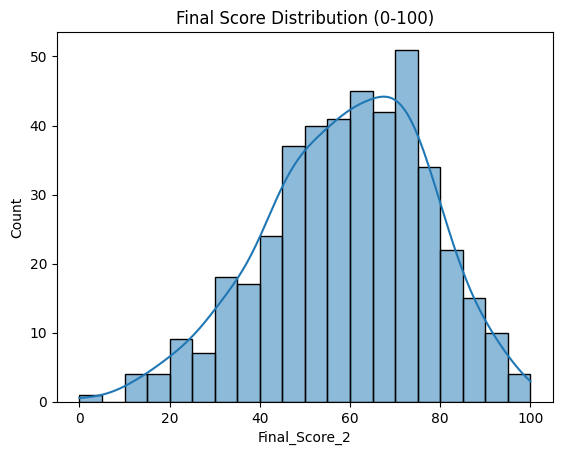

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_df['Final_Score_2'], bins=20, kde=True)
plt.title('Final Score Distribution (0-100)')
plt.show()

## 지수 3 - PCA 가중치

In [46]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 대상 컬럼 설정
target_cols = ['ELDERLY_SCORE', 'disabled_index', 'PVI', '1인가구_지수', '사회적_고립도']
df_pca = final_df[target_cols].copy()

# 2. 데이터 표준화 (PCA 실행 전 필수 단계)
# 이미 0~100 스케일이더라도, 변수 간의 분산을 공정하게 비교하기 위해 StandardScaler를 사용합니다.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

# 3. PCA 모델 학습
# 모든 변수를 설명할 수 있는 주성분을 추출합니다.
pca = PCA(n_components=len(target_cols))
pca.fit(df_scaled)

# 4. 제1주성분(PC1)의 로딩값(Loadings) 추출
# PC1은 데이터의 전체적인 '취약성 트렌드'를 가장 잘 나타내는 축입니다.
pc1_loadings = pca.components_[0]

# 5. 가중치 변환
# 로딩값의 절대값을 취한 뒤, 전체 합이 1(100%)이 되도록 정규화합니다.
weights = np.abs(pc1_loadings)
normalized_weights = weights / np.sum(weights)

# 6. 결과 출력
pca_weights_df = pd.DataFrame({
    'Indicator': target_cols,
    'Weight': normalized_weights
}).sort_values(by='Weight', ascending=False)

print("--- PCA 기반 산출 가중치 결과 ---")
print(pca_weights_df)

# 설명력(Explained Variance) 확인
print(f"\n제1주성분의 설명력: {pca.explained_variance_ratio_[0] * 100:.2f}%")

--- PCA 기반 산출 가중치 결과 ---
        Indicator    Weight
2             PVI  0.266816
4         사회적_고립도  0.256611
3         1인가구_지수  0.216059
1  disabled_index  0.156727
0   ELDERLY_SCORE  0.103787

제1주성분의 설명력: 42.34%


In [47]:
# Demand(수요지수) 계산
final_df['Demand_3'] = (0.103787 * final_df['ELDERLY_SCORE'] +
                        0.156727 * final_df['disabled_index'] +
                        0.266816 * final_df['PVI'] +
                        0.216059 * final_df['1인가구_지수'] +
                        0.256611 * final_df['사회적_고립도'])

# 1. 기하평균(Geometric Mean) 방식으로 Raw Score 산출
# 수요와 공급 결핍의 상호 증폭 효과를 반영합니다.
final_df['raw_score_3'] = np.sqrt(final_df['Demand_3'] * final_df['Supply'])

# 2. 0~100 범위로 재정규화 (Min-Max Scaling)
# 점수 분포를 넓게 펼쳐 행정동 간의 변별력을 극대화합니다.
min_val = final_df['raw_score_3'].min()
max_val = final_df['raw_score_3'].max()

final_df['Final_Score_3'] = ((final_df['raw_score_3'] - min_val) / (max_val - min_val)) * 100

# 3. 반올림 후 정수형(int)으로 변환
final_df['Final_Score_3'] = final_df['Final_Score_3'].round().astype(int)

# 결과 확인
final_df[['자치구', '행정동', 'Demand_3', 'Supply', 'Final_Score_3']].head(10)

,자치구,행정동,Demand_3,Supply,Final_Score_3
0,종로구,사직동,30.267857,27.6,20
1,종로구,삼청동,34.108684,34.4,32
2,종로구,부암동,31.260081,48.2,43
3,종로구,평창동,25.469777,52.6,38
4,종로구,무악동,42.128029,43.5,52
5,종로구,교남동,48.508154,41.5,57
6,종로구,가회동,42.335975,33.6,40
7,종로구,종로1·2·3·4가동,39.230626,57.0,63
8,종로구,종로5·6가동,48.651789,51.7,69
9,종로구,이화동,43.052997,34.7,42


In [48]:
final_df[['행정동코드', '자치구', '행정동', 'Demand_3', 'Supply', 'Final_Score_3']].to_csv(
    'final_score_PCA.csv',
    index=False,
    encoding='utf-8-sig'
)

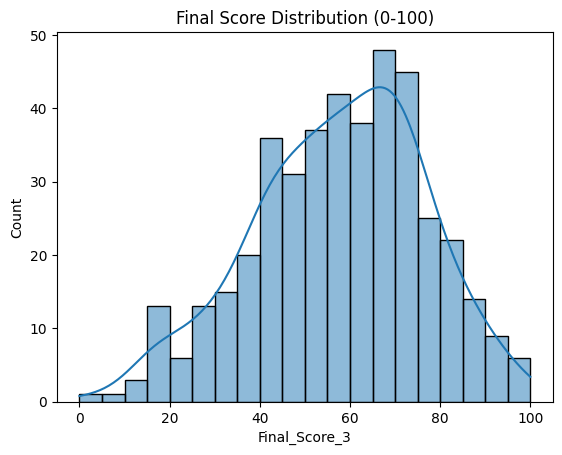

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_df['Final_Score_3'], bins=20, kde=True)
plt.title('Final Score Distribution (0-100)')
plt.show()

## 지수 4 노인, 장애인, 저소득 동일 가중치

In [50]:
# Demand(수요지수) 계산
final_df['Demand_4'] = (0.7 * 1/3 * final_df['ELDERLY_SCORE'] +
                        0.7 * 1/3 * final_df['disabled_index'] +
                        0.7 * 1/3 * final_df['PVI'] +
                        0.1 * final_df['1인가구_지수'] +
                        0.2 * final_df['사회적_고립도'])

# 1. 기하평균(Geometric Mean) 방식으로 Raw Score 산출
# 수요와 공급 결핍의 상호 증폭 효과를 반영합니다.
final_df['raw_score_4'] = np.sqrt(final_df['Demand_4'] * final_df['Supply'])

# 2. 0~100 범위로 재정규화 (Min-Max Scaling)
# 점수 분포를 넓게 펼쳐 행정동 간의 변별력을 극대화합니다.
min_val = final_df['raw_score_4'].min()
max_val = final_df['raw_score_4'].max()

final_df['Final_Score_4'] = ((final_df['raw_score_4'] - min_val) / (max_val - min_val)) * 100

# 3. 반올림 후 정수형(int)으로 변환
final_df['Final_Score_4'] = final_df['Final_Score_4'].round().astype(int)

# 결과 확인
final_df[['자치구', '행정동', 'Demand_4', 'Supply', 'Final_Score_4']].head(10)

,자치구,행정동,Demand_4,Supply,Final_Score_4
0,종로구,사직동,32.866667,27.6,22
1,종로구,삼청동,36.166667,34.4,34
2,종로구,부암동,35.033333,48.2,47
3,종로구,평창동,33.600000,52.6,49
4,종로구,무악동,45.133333,43.5,54
5,종로구,교남동,50.466667,41.5,58
6,종로구,가회동,44.900000,33.6,42
7,종로구,종로1·2·3·4가동,44.400000,57.0,68
8,종로구,종로5·6가동,51.100000,51.7,70
9,종로구,이화동,38.033333,34.7,36


In [66]:

# 3. 결과 확인 (상위 10개 행정동)
final_result = final_df.sort_values(by='Final_Score_4', ascending=False).head(14)

# 가독성을 위해 필요한 컬럼만 출력
final_result[['자치구', '행정동', 'ELDERLY_SCORE', 'PVI','disabled_index', '1인가구_지수', '사회적_고립도','DISASTER_SCORE', 'CRIME_SCORE','인프라지수', 'HVI_index', 'Demand_4', 'Supply', 'Final_Score_4']]

,자치구,행정동,ELDERLY_SCORE,PVI,disabled_index,1인가구_지수,사회적_고립도,DISASTER_SCORE,CRIME_SCORE,인프라지수,HVI_index,Demand_4,Supply,Final_Score_4
327,관악구,신원동,57,47,71,38,78,36,74,63,94,60.233333,69.1,100
320,관악구,청림동,58,45,84,32,79,35,54,66,81,62.633333,61.9,95
251,강서구,가양2동,77,67,59,73,93,19,85,48,59,73.266667,52.9,95
293,영등포구,신길4동,58,48,77,42,88,42,84,55,62,64.500000,60.3,95
263,구로구,구로4동,67,42,83,42,89,51,92,27,68,66.800000,57.1,94
131,강북구,번2동,67,51,33,52,95,37,66,49,98,59.433333,64.7,94
137,강북구,미아동,58,46,70,43,85,44,78,26,95,61.900000,60.7,93
11,종로구,창신2동,53,60,80,52,83,35,23,81,69,66.833333,56.6,93
337,관악구,난곡동,68,60,74,48,89,27,55,45,78,69.733333,53.3,92
226,양천구,신월1동,55,75,37,44,73,39,65,63,77,57.966667,62.8,91


In [52]:
final_df[['행정동코드', '자치구', '행정동', 'Demand_4', 'Supply', 'Final_Score_4']].to_csv(
    'final_score_4.csv',
    index=False,
    encoding='utf-8-sig'
)

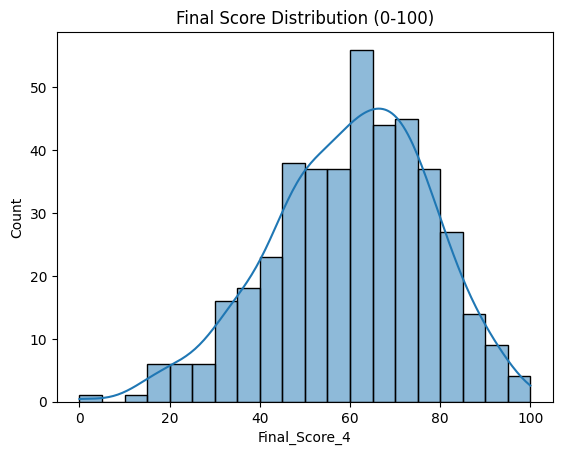

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_df['Final_Score_4'], bins=20, kde=True)
plt.title('Final Score Distribution (0-100)')
plt.show()

# 분석


In [54]:
import pandas as pd
import numpy as np
from scipy import stats
import libpysal
from esda.moran import Moran


model_cols = ['Final_Score_1', 'Final_Score_2', 'Final_Score_3', 'Final_Score_4']

def analyze_distribution(df, cols):
    dist_results = []
    for col in cols:
        std = df[col].std()
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        dist_results.append({
            'Model': col,
            'Std Dev': round(std, 3),
            'IQR': round(iqr, 3),
            'Min': df[col].min(),
            'Max': df[col].max()
        })
    return pd.DataFrame(dist_results)

dist_df = analyze_distribution(final_df, model_cols)
print("--- 분포 분석 결과 ---")
print(dist_df)

--- 분포 분석 결과 ---
           Model  Std Dev   IQR  Min  Max
0  Final_Score_1   18.719  24.0    0  100
1  Final_Score_2   17.995  25.0    0  100
2  Final_Score_3   18.988  27.0    0  100
3  Final_Score_4   17.373  23.0    0  100


In [55]:
def get_gini(x):
    # 데이터 정렬 및 음수 처리 (0~100 스케일이므로 양수 가정)
    data = np.sort(x)
    n = len(data)
    index = np.arange(1, n + 1)
    # 지니계수 공식 적용
    return ((np.sum((2 * index - n - 1) * data)) / (n * np.sum(data)))

gini_results = {col: round(get_gini(final_df[col].values), 4) for col in model_cols}
print("\n--- 모델별 지니 계수 ---")
for model, gini in gini_results.items():
    print(f"{model}: {gini}")


--- 모델별 지니 계수 ---
Final_Score_1: 0.1795
Final_Score_2: 0.1713
Final_Score_3: 0.1866
Final_Score_4: 0.1631


In [56]:
import geopandas as gpd
admin_gdf = gpd.read_file('/content/drive/MyDrive/비타민/서울시 공모전/bnd_dong_11_2025_2Q.shp', encoding='utf-8')

In [57]:
import pandas as pd
from shapely.ops import unary_union

# 1. 상일1동 -> 상일동 명칭 수정
admin_gdf.loc[admin_gdf['ADM_NM'] == '상일1동', 'ADM_NM'] = '상일동'

# 2. 강일동과 상일2동 geometry 통합
# 강일동과 상일2동의 geometry만 추출
gangil_geom = admin_gdf[admin_gdf['ADM_NM'] == '강일동'].geometry.values[0]
sangil2_geom = admin_gdf[admin_gdf['ADM_NM'] == '상일2동'].geometry.values[0]

# 두 geometry를 합침 (unary_union)
combined_geom = unary_union([gangil_geom, sangil2_geom])

# 강일동 행의 geometry를 합쳐진 geometry로 업데이트
admin_gdf.loc[admin_gdf['ADM_NM'] == '강일동', 'geometry'] = combined_geom

# 3. 상일2동 행 제거
admin_gdf = admin_gdf[admin_gdf['ADM_NM'] != '상일2동'].reset_index(drop=True)

In [58]:
# 1. 데이터 타입 통일 (병합 오류 방지)
# 두 데이터프레임의 행정동코드 컬럼을 문자열로 통일합니다.
final_df['행정동코드'] = final_df['행정동코드'].astype(str).str.strip()
admin_gdf['ADM_CD'] = admin_gdf['ADM_CD'].astype(str).str.strip()

# 2. 행정동코드를 기준으로 geometry 컬럼만 병합
# admin_gdf에서 코드와 형상 정보만 추출하여 병합합니다.
final_gdf = final_df.merge(
    admin_gdf[['ADM_CD', 'geometry']],
    left_on='행정동코드',
    right_on='ADM_CD',
    how='left'
)

# 3. 불필요해진 ADM_CD 컬럼 제거 및 GeoDataFrame 선언
final_gdf = final_gdf.drop(columns=['ADM_CD'])
final_gdf = gpd.GeoDataFrame(final_gdf, geometry='geometry', crs="EPSG:5179")

# 4. 결과 확인
print("--- 공간 데이터(final_gdf) 병합 완료 ---")
print(len(final_gdf))
display(final_gdf.head())

--- 공간 데이터(final_gdf) 병합 완료 ---
425


,행정동코드,자치구,행정동,ELDERLY_SCORE,PVI,disabled_index,1인가구_지수,사회적_고립도,HVI_index,인프라지수,...,Demand_2,raw_score_2,Final_Score_2,Demand_3,raw_score_3,Final_Score_3,Demand_4,raw_score_4,Final_Score_4,geometry
0,11010530,종로구,사직동,69,11,6,32,48,34,12,...,33.2,30.270778,22,30.267857,28.903163,20,32.866667,30.118433,22,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11010540,종로구,삼청동,42,9,53,43,38,5,63,...,37.0,35.676323,35,34.108684,34.254032,32,36.166667,35.272274,34,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,11010550,종로구,부암동,46,15,51,35,27,47,75,...,34.8,40.955586,47,31.260081,38.816696,43,35.033333,41.092660,47,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,11010560,종로구,평창동,57,13,53,17,16,35,83,...,31.2,40.510739,46,25.469777,36.602053,38,33.600000,42.039981,49,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,11010570,종로구,무악동,48,18,61,33,61,35,78,...,44.2,43.848603,54,42.128029,42.808519,52,45.133333,44.309141,54,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [59]:
# Queen 인접성 가중치 생성 (이미 생성했다면 재사용 가능)
w = libpysal.weights.Queen.from_dataframe(final_gdf)
w.transform = 'R' # 행 표준화

def analyze_moran(df, cols, weights):
    moran_results = []
    for col in cols:
        mi = Moran(df[col], weights)
        moran_results.append({
            'Model': col,
            'Moran\'s I': round(mi.I, 4),
            'P-value': round(mi.p_sim, 4)
        })
    return pd.DataFrame(moran_results)

moran_df = analyze_moran(final_gdf, model_cols, w)
print("\n--- 공간적 자기상관 (Moran's I) ---")
print(moran_df)

/tmp/ipykernel_656/3869631339.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(final_gdf)



--- 공간적 자기상관 (Moran's I) ---
           Model  Moran's I  P-value
0  Final_Score_1     0.3336    0.001
1  Final_Score_2     0.3748    0.001
2  Final_Score_3     0.4339    0.001
3  Final_Score_4     0.3679    0.001


# 시각화

In [60]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m1 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 치안의 엄중함을 나타내기 위해 'RdPu'(빨강-보라) 또는 'YlOrRd' 색상 추천
folium.Choropleth(
    geo_data=final_gdf,
    data=final_gdf,
    columns=['행정동', 'Final_Score_1'],
    key_on='feature.properties.행정동', # final_gdf '행정동' 속성이 있는 경우
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='지수1 (Final_Score_1)'
).add_to(m1)

# 3. 툴팁(Tooltip) 추가: 마우스를 올리면 상세 정보 표시
# final_gdf geometry 정보를 활용하여 GeoJson 레이어 추가
folium.features.GeoJson(
    final_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'Final_Score_1'],
        aliases=['자치구: ', '행정동: ', '최종 지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m1)

# 4. 결과 저장 및 출력
m1.save('seoul_map1.html')
m1

Output hidden; open in https://colab.research.google.com to view.

In [61]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m2 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 치안의 엄중함을 나타내기 위해 'RdPu'(빨강-보라) 또는 'YlOrRd' 색상 추천
folium.Choropleth(
    geo_data=final_gdf,
    data=final_gdf,
    columns=['행정동', 'Final_Score_2'],
    key_on='feature.properties.행정동', # final_gdf '행정동' 속성이 있는 경우
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='지수2 (Final_Score_2)'
).add_to(m2)

# 3. 툴팁(Tooltip) 추가: 마우스를 올리면 상세 정보 표시
# final_gdf geometry 정보를 활용하여 GeoJson 레이어 추가
folium.features.GeoJson(
    final_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'Final_Score_2'],
        aliases=['자치구: ', '행정동: ', '최종 지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m2)

# 4. 결과 저장 및 출력
m2.save('seoul_map2.html')
m2

Output hidden; open in https://colab.research.google.com to view.

In [62]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m3 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 치안의 엄중함을 나타내기 위해 'RdPu'(빨강-보라) 또는 'YlOrRd' 색상 추천
folium.Choropleth(
    geo_data=final_gdf,
    data=final_gdf,
    columns=['행정동', 'Final_Score_3'],
    key_on='feature.properties.행정동', # final_gdf '행정동' 속성이 있는 경우
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='지수3 (Final_Score_3)'
).add_to(m3)

# 3. 툴팁(Tooltip) 추가: 마우스를 올리면 상세 정보 표시
# final_gdf geometry 정보를 활용하여 GeoJson 레이어 추가
folium.features.GeoJson(
    final_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'Final_Score_3'],
        aliases=['자치구: ', '행정동: ', '최종 지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m3)

# 4. 결과 저장 및 출력
m3.save('seoul_map3.html')
m3

Output hidden; open in https://colab.research.google.com to view.

In [63]:
import folium

# 1. 지도 중심 설정 (서울 중심부)
m4 = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 2. 단계구분도(Choropleth) 추가
# 치안의 엄중함을 나타내기 위해 'RdPu'(빨강-보라) 또는 'YlOrRd' 색상 추천
folium.Choropleth(
    geo_data=final_gdf,
    data=final_gdf,
    columns=['행정동', 'Final_Score_4'],
    key_on='feature.properties.행정동', # final_gdf '행정동' 속성이 있는 경우
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='최종 지수'
).add_to(m4)

# 3. 툴팁(Tooltip) 추가: 마우스를 올리면 상세 정보 표시
# final_gdf geometry 정보를 활용하여 GeoJson 레이어 추가
folium.features.GeoJson(
    final_gdf,
    style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.0, 'weight': 0.1},
    highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.3, 'weight': 0.1},
    tooltip=folium.features.GeoJsonTooltip(
        fields=['자치구', '행정동', 'Final_Score_4'],
        aliases=['자치구: ', '행정동: ', '최종 지수: '],
        style="background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;"
    )
).add_to(m4)

# 4. 결과 저장 및 출력
m4.save('seoul_map4.html')
m4

Output hidden; open in https://colab.research.google.com to view.

In [64]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran_Local

# 1. 데이터 결합 (SHP + final_df)
# shp의 행정동코드와 df의 코드가 일치해야 합니다.
gdf = shp.merge(final_df, on='행정동코드')

# 2. 3.4.2 자치구별 수요 집중도 계산
gu_summary = final_df.groupby('자치구')['Final_Score_4'].agg(['mean', 'std', 'max']).sort_values(by='mean', ascending=False)

# 3. 3.4.3 공간적 패턴 분석 (LISA: Local Indicators of Spatial Association)
w = libpysal.weights.Queen.from_dataframe(gdf)
w.transform = 'R'
lisa = Moran_Local(gdf['Final_Score_4'], w)

# 고수요 군집(High-High) 지역 추출 (p-value 0.05 기준)
gdf['lisa_cluster'] = lisa.q
gdf['lisa_p'] = lisa.p_sim
# 1: HH, 2: LH, 3: LL, 4: HL (보통 1번인 High-High가 핵심 타겟)
hh_zones = gdf[(gdf['lisa_cluster'] == 1) & (gdf['lisa_p'] <= 0.05)]['행정동_x'].tolist()

NameError: name 'shp' is not defined